# Titanic ML Problem Type Explorer

## Goal

Use the Titanic dataset to understand:

- Supervised Learning
- Classification
- Features and Labels
- Overfitting intuition
- Basic ML workflow

---

## Problem Type

We want to predict whether a passenger survived or not.

This is:

- Supervised Learning
- Binary Classification

Why?

Because:
- We already know the correct answers (labels)
- Output has two categories:
  - Survived
  - Did Not Survive


In [114]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [115]:
df = sns.load_dataset("titanic")

In [116]:
print(df.head())
df.shape

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


(891, 15)

In [117]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

We inspect:
- numerical columns
- categorical columns
- missing values

ML models usually require:
- clean data
- numerical features

In [118]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


In [119]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [120]:
df["age"] = df["age"].fillna(df["age"].median())

df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# 1. Add "Unknown" to the pre-approved list of categories
df["deck"] = df["deck"].cat.add_categories("Unknown")
df["deck"] = df["deck"].fillna("Unknown")

In [121]:
df = df[[ "survived",
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"]]

0 = Did Not Survive

1 = Survived

This shows class distribution.

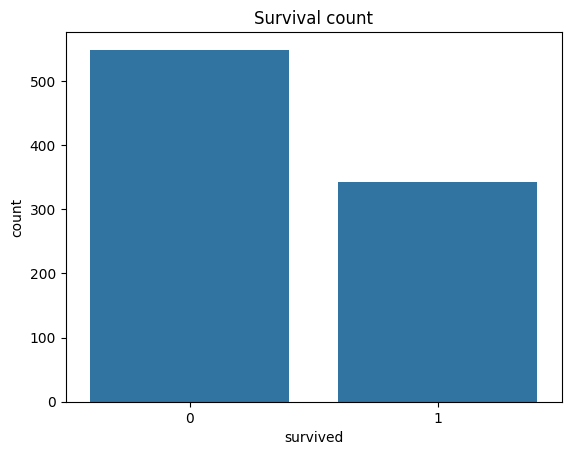

In [122]:
sns.countplot(data = df, x = "survived")

plt.title("Survival count")
plt.show()

Histograms help us understand feature distributions.

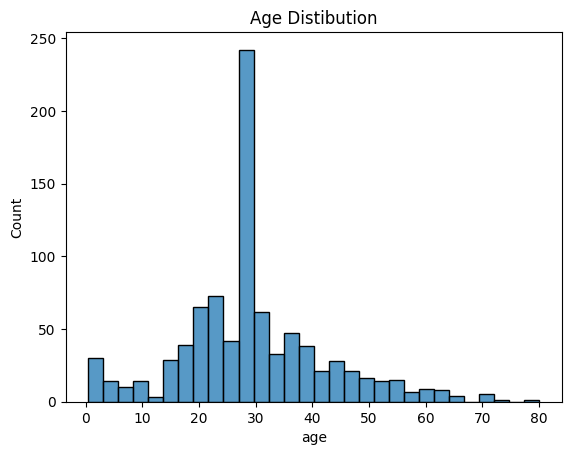

In [123]:
###plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=30)

plt.title("Age Distibution")
plt.show()

This helps us identify relationships between features and target labels.

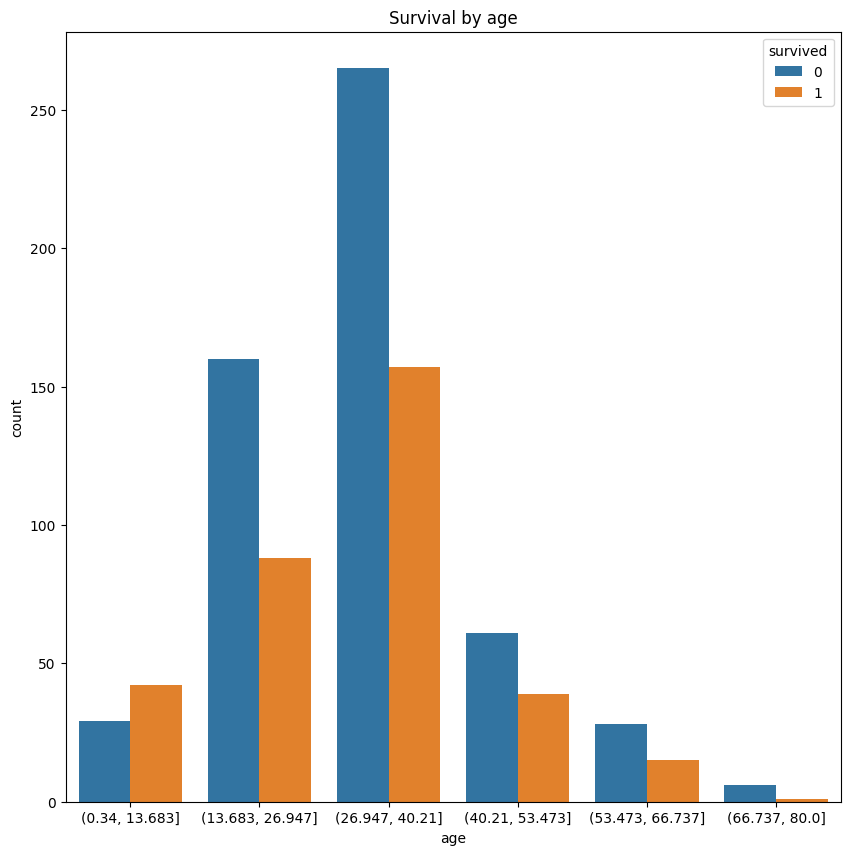

In [124]:
plt.figure(figsize=(10,10))

df_copy = df.copy()
df_copy["age"] = pd.cut(df_copy["age"] , bins= 6)
sns.countplot(data= df_copy,x = "age",hue = "survived")

plt.title("Survival by age")
plt.show()

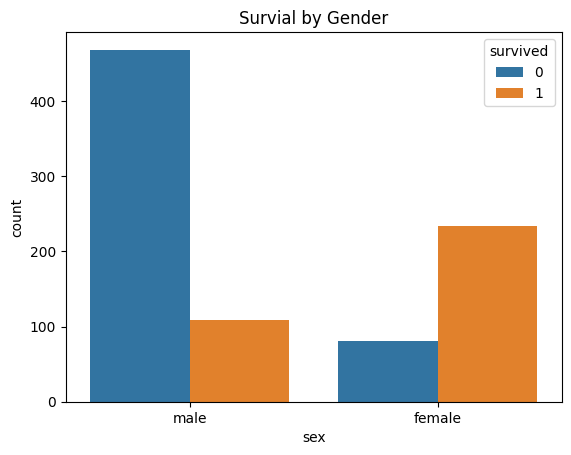

In [125]:
sns.countplot(data = df, x ="sex", hue = "survived" )

plt.title("Survial by Gender")
plt.show()

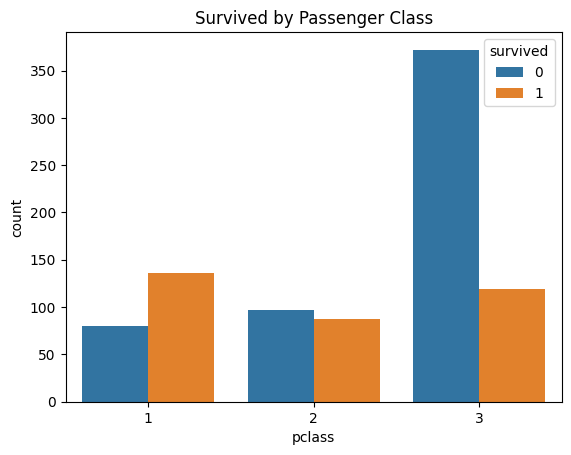

In [126]:
sns.countplot(data =df, x = "pclass",hue = "survived" )

plt.title("Survived by Passenger Class")
plt.show()

# ML Problem Type Analysis

## Is this supervised learning?

Yes.

Why?

Because the dataset contains labels:
- survived = 0 or 1

---

## Is this classification or regression?

Classification.

Why?

Because we predict categories:
- survived
- not survived

The output is NOT a continuous number.

Machine learning models usually cannot understand text directly.

We convert categories into numbers.

In [127]:
encoder = LabelEncoder()

df["sex"] = encoder.fit_transform(df["sex"])
print(df["sex"])

df["embarked"] = encoder.fit_transform(df["embarked"])
print(df["embarked"])

0      1
1      0
2      0
3      0
4      1
      ..
886    1
887    0
888    0
889    1
890    1
Name: sex, Length: 891, dtype: int64
0      2
1      0
2      2
3      2
4      2
      ..
886    2
887    2
888    2
889    0
890    1
Name: embarked, Length: 891, dtype: int64


X = input features

y = target labels

In [128]:
x = df.drop("survived", axis = 1)

y = df["survived"]

Why split data?

We train on one part
and evaluate on unseen data.

This helps measure generalization.

In [129]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [130]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [131]:
y_pred = log_model.predict(x_test)

Accuracy measures:

correct predictions / total predictions

In [132]:
accuracy_score(y_test,y_pred)

0.8100558659217877

In [133]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



[[90 15]
 [19 55]]


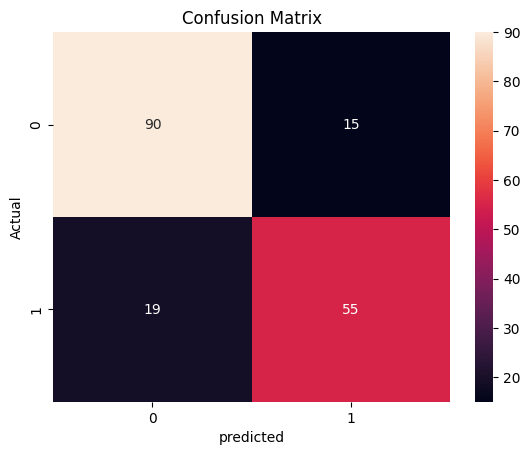

In [134]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt = "d")

plt.title("Confusion Matrix")
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.show()

Decision Tree model

0.7988826815642458
[[96  9]
 [27 47]]


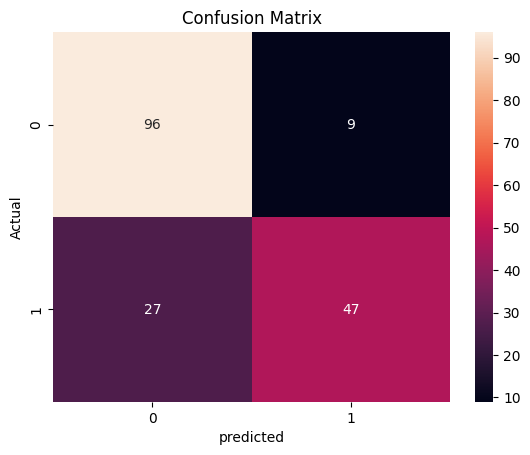

In [139]:
tree_model = DecisionTreeClassifier(max_depth = 4)
tree_model.fit(x_train,y_train)
tree_pred = tree_model.predict(x_test)

print(accuracy_score(y_test, tree_pred))

cm = confusion_matrix(y_test, tree_pred)
print(cm)
sns.heatmap(cm, annot=True, fmt = "d")

plt.title("Confusion Matrix")
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.show()

Random Forest Model

0.8100558659217877
[[89 16]
 [18 56]]


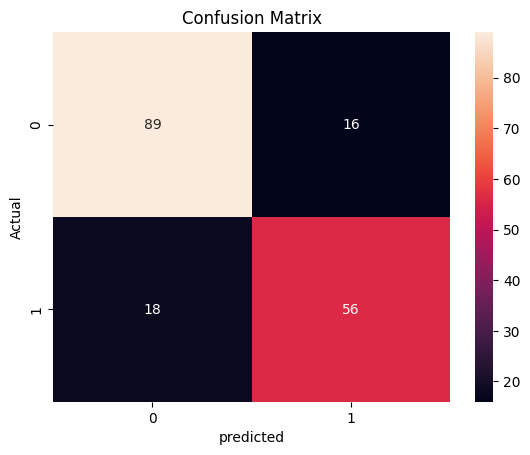

In [141]:
rf_model = RandomForestClassifier()

rf_model.fit(x_train, y_train)

rf_preds = rf_model.predict(x_test)

print(accuracy_score(y_test, rf_preds))

cm = confusion_matrix(y_test, rf_preds)
print(cm)
sns.heatmap(cm, annot=True, fmt = "d")

plt.title("Confusion Matrix")
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.show()

# Algorithm Comparison

## Logistic Regression
Good for:
- simple binary classification
- interpretable predictions

---

## Decision Tree
Good for:
- learning decision rules
- handling non-linear patterns

---

## Random Forest
Good for:
- reducing overfitting
- improving accuracy
- combining multiple trees

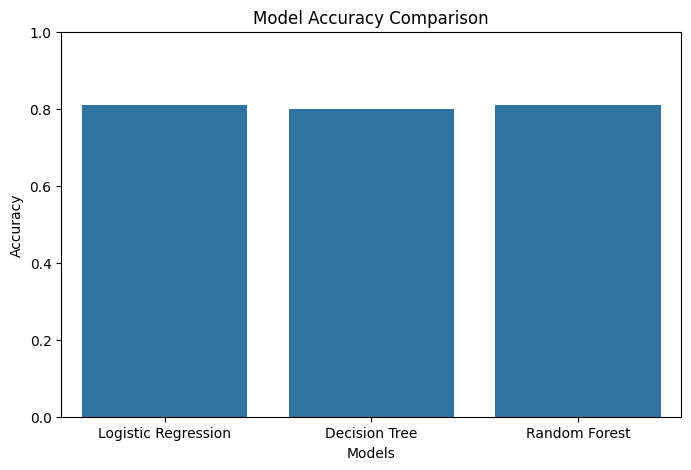

In [143]:
log_acc = accuracy_score(y_test, y_pred)

tree_acc = accuracy_score(y_test, tree_pred)

rf_acc = accuracy_score(y_test, rf_preds)


models = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest"
]

accuracies = [
    log_acc,
    tree_acc,
    rf_acc
]

plt.figure(figsize=(8,5))

sns.barplot(
    x=models,
    y=accuracies
)

plt.ylim(0,1)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.xlabel("Models")

plt.show()